# Case Study II: Visualisierungen von Kundendaten

In [1]:
# Import von Programmbibliotheken

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Einlesen des Datensatzes, Anzeigen der ersten Zeilen

df = pd.read_csv('customers.csv')
df.head()

,customerID,gender,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,1,No,DSL,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,34,Yes,DSL,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,2,Yes,DSL,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,45,No,DSL,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,2,Yes,Fiber optic,Month-to-month,Electronic check,70.70,151.65,Yes


### Umgang mit fehlenden Werten (Null Values)

In [3]:
# Option 1: Entfernen der Zeilen

#df.dropna(inplace=True)

# Option 2: MonthlyCharges = TotalCharges

df_null = df[df.isnull().any(axis=1)]
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])
#nan_indices = df_null.index
#df.iloc[nan_indices]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   tenure           7043 non-null   int64  
 3   PhoneService     7043 non-null   object 
 4   InternetService  7043 non-null   object 
 5   Contract         7043 non-null   object 
 6   PaymentMethod    7043 non-null   object 
 7   MonthlyCharges   7043 non-null   float64
 8   TotalCharges     7043 non-null   float64
 9   Churn            7043 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 550.4+ KB


## Datenvisualisierung

### Histogramme zur Visualisierung kategorischer Variablen

(array([3488.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        3555.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

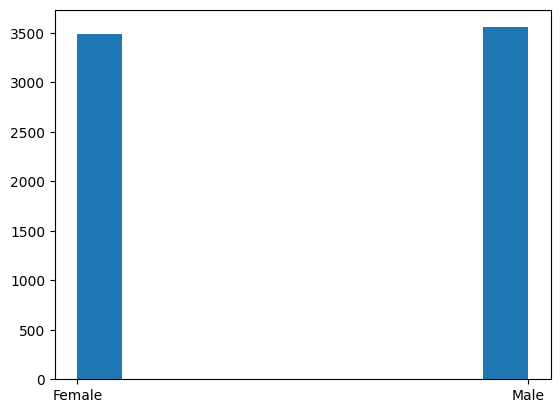

In [4]:
# Histogramme (mehrere Möglichkeiten)

plt.hist(data=df, x='gender')
#sns.histplot(data=df, x='gender')
#sns.countplot(data=df, x='gender')
#sns.displot(data=df, x='gender', kind='hist')

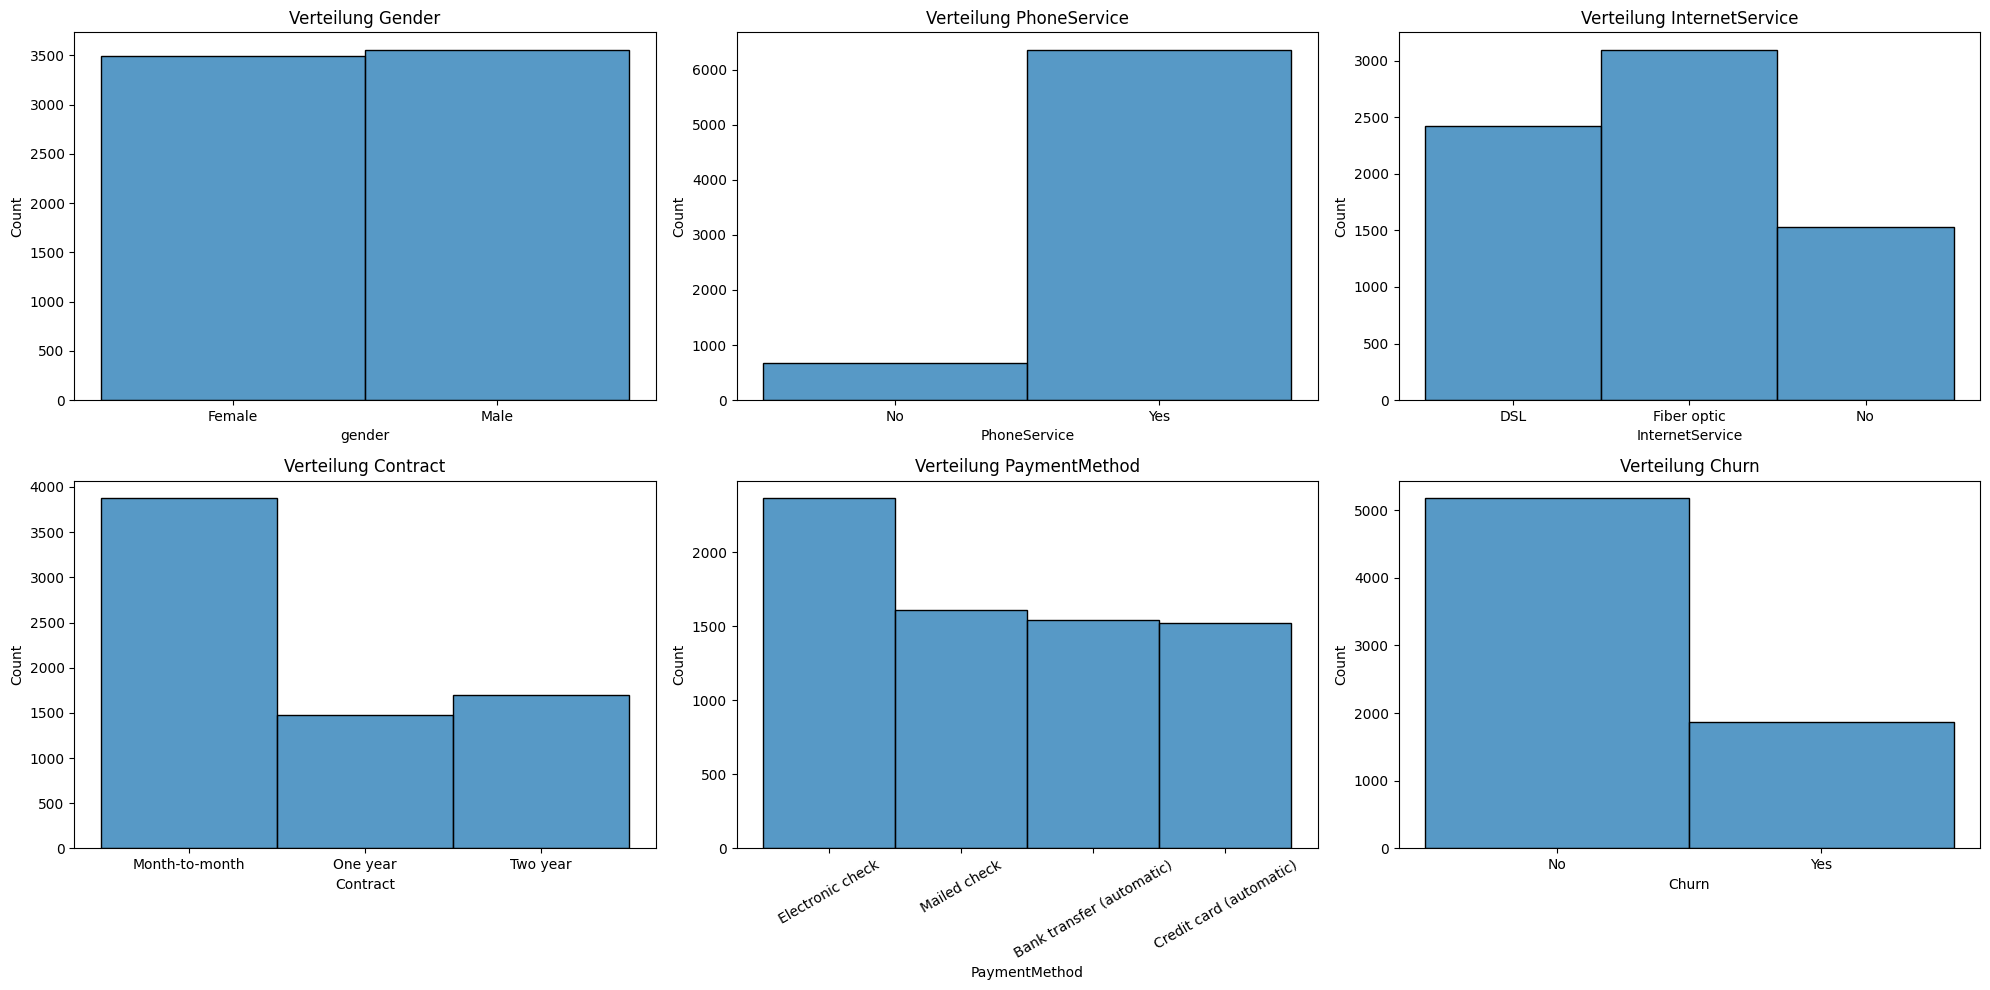

In [5]:
# Kompaktere Darstellung: Subplots (https://stackoverflow.com/questions/34162443/why-do-many-examples-use-fig-ax-plt-subplots)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

#sns.histplot(data=df, x='gender', ax=axes[0, 0])
sns.histplot(x=df['gender'], ax=axes[0, 0])
axes[0, 0].set_title('Verteilung Gender')

sns.histplot(data=df, x='PhoneService', ax=axes[0, 1])
axes[0, 1].set_title('Verteilung PhoneService')

sns.histplot(data=df, x='InternetService', ax=axes[0, 2])
axes[0, 2].set_title('Verteilung InternetService')

sns.histplot(data=df, x='Contract', ax=axes[1, 0])
axes[1, 0].set_title('Verteilung Contract')

sns.histplot(data=df, x='PaymentMethod', ax=axes[1, 1])
axes[1, 1].set_title('Verteilung PaymentMethod')
axes[1, 1].tick_params(axis='x', rotation=30) # zur besseren Übersicht

sns.histplot(data=df, x='Churn', ax=axes[1, 2])
axes[1, 2].set_title('Verteilung Churn')

plt.tight_layout()
plt.show()

<Axes: ylabel='count'>

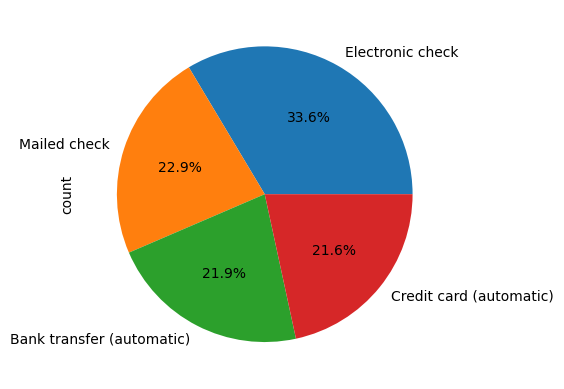

In [6]:
# Visualisierung direkt mit Pandas möglich (z.B. Pie-Chart)

df.PaymentMethod.value_counts().plot(kind='pie', autopct='%.1f%%')

In [7]:
# Erinnerung: Groupby nach Churn

df.groupby(['Churn', 'gender']).size()

Churn  gender
No     Female    2549
       Male      2625
Yes    Female     939
       Male       930
dtype: int64

In [8]:
# Übersichtlichere Darstellung

churn_payment = df.groupby(['Churn', 'PaymentMethod']).size().unstack()
churn_payment

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,1286,1290,1294,1304
Yes,258,232,1071,308


In [9]:
# Mit Prozentangabe

churn_internet = df.groupby(['Churn', 'InternetService']).size().unstack()
perc = churn_internet.div(churn_internet.sum(axis=1), axis=0) * 100
perc.round(2)

InternetService,DSL,Fiber optic,No
Churn,,,
No,37.92,34.77,27.31
Yes,24.56,69.40,6.05


<Axes: ylabel='count'>

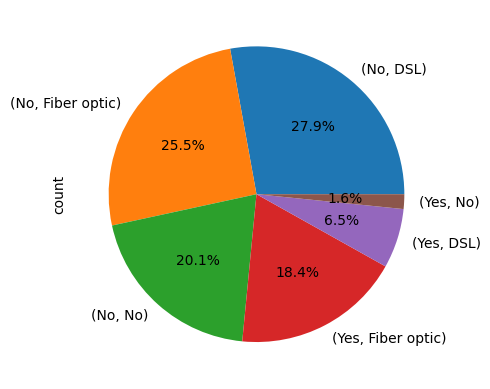

In [10]:
# Als Pie-Chart

df.groupby("Churn").InternetService.value_counts().plot(kind="pie", autopct='%.1f%%')

<Axes: ylabel='count'>

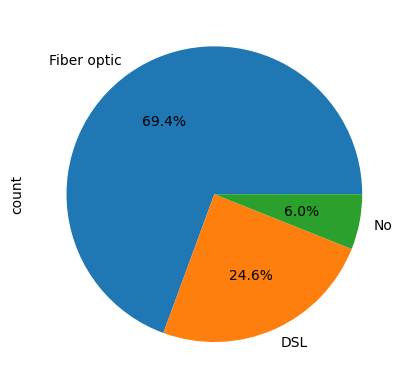

In [11]:
# Gefiltert nach Churn == Yes

df[df["Churn"] == "Yes"]["InternetService"].value_counts().plot(kind="pie", autopct="%.1f%%")

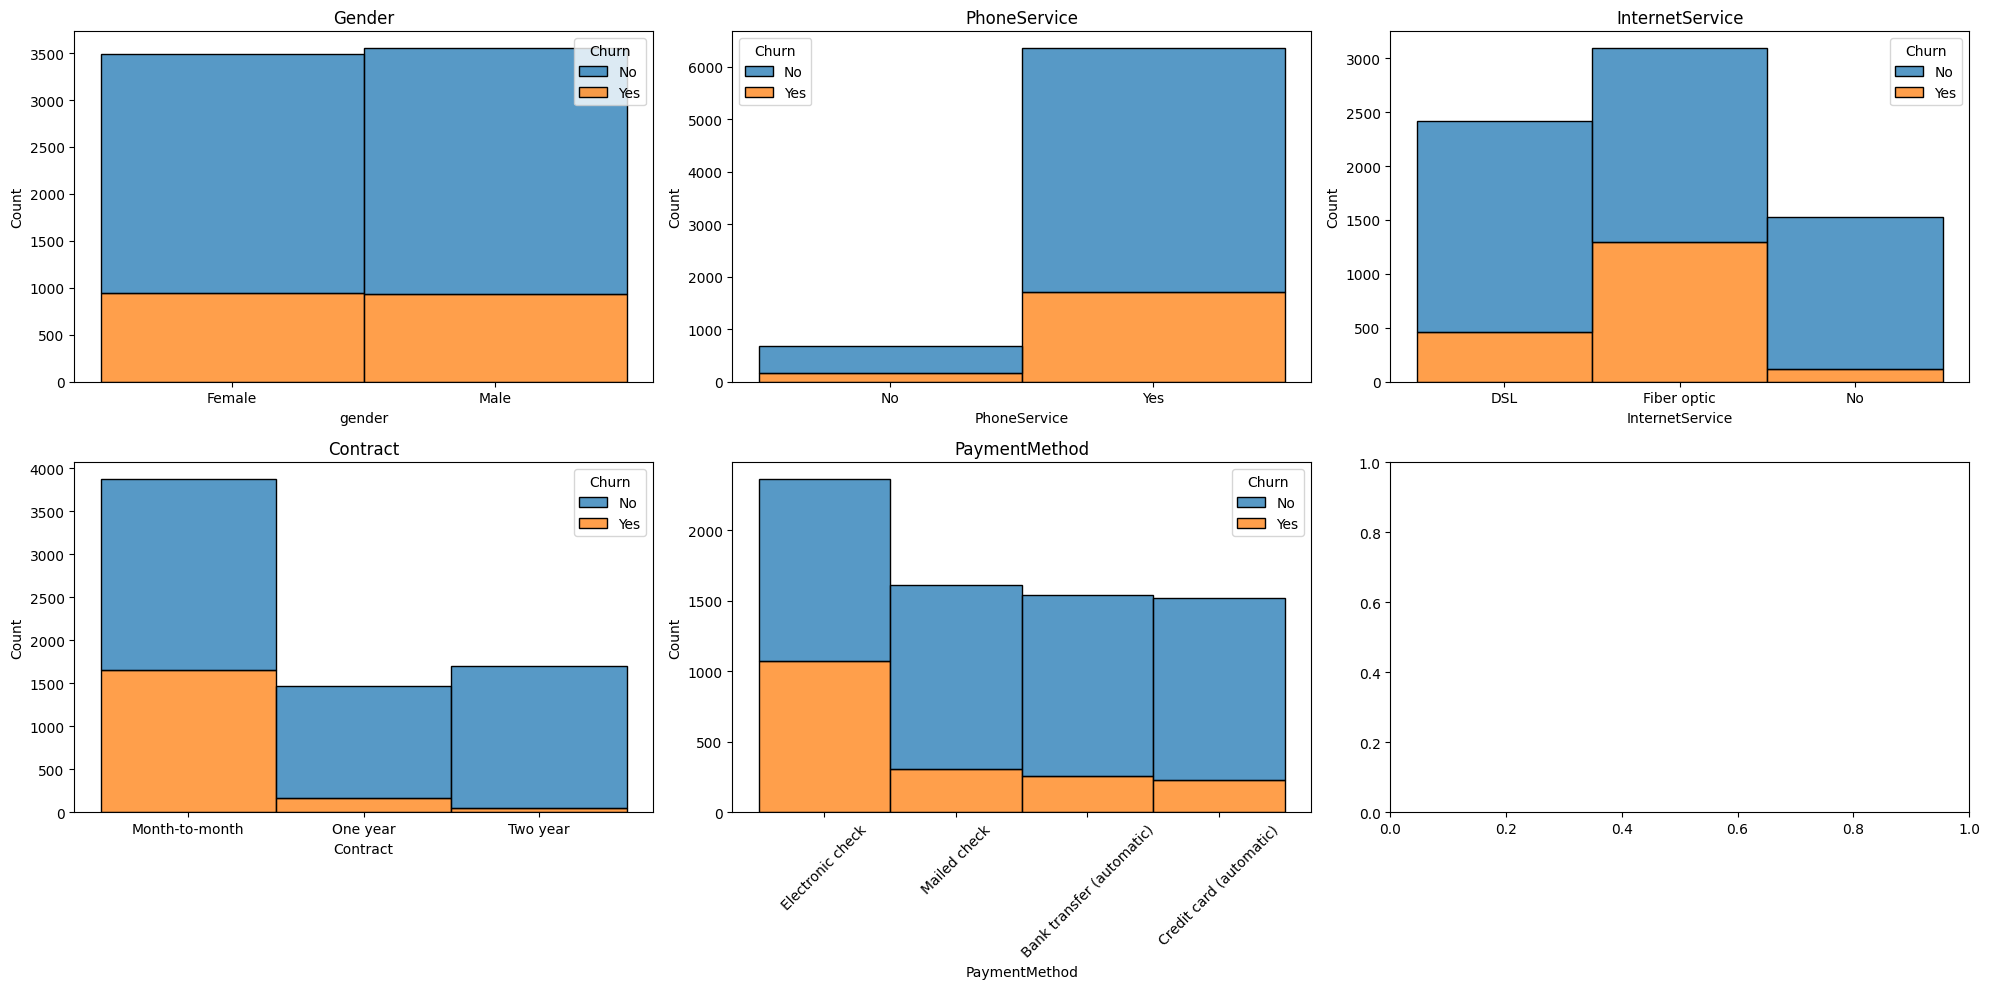

In [12]:
# Gleiche Subplots in Abhängigkeit von Churn

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.histplot(data=df, x='gender', hue='Churn', multiple='stack', ax=axes[0, 0]) 
axes[0, 0].set_title('Gender')

sns.histplot(data=df, x='PhoneService', hue='Churn', multiple='stack', ax=axes[0, 1])
axes[0, 1].set_title('PhoneService')

sns.histplot(data=df, x='InternetService', hue='Churn', multiple='stack', ax=axes[0, 2])
axes[0, 2].set_title('InternetService')

sns.histplot(data=df, x='Contract', hue='Churn', multiple='stack', ax=axes[1, 0])
axes[1, 0].set_title('Contract')

sns.histplot(data=df, x='PaymentMethod', hue='Churn', multiple='stack', ax=axes[1, 1])
axes[1, 1].set_title('PaymentMethod')
axes[1, 1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

### Boxplots zur Visualisierung numerischer Variablen

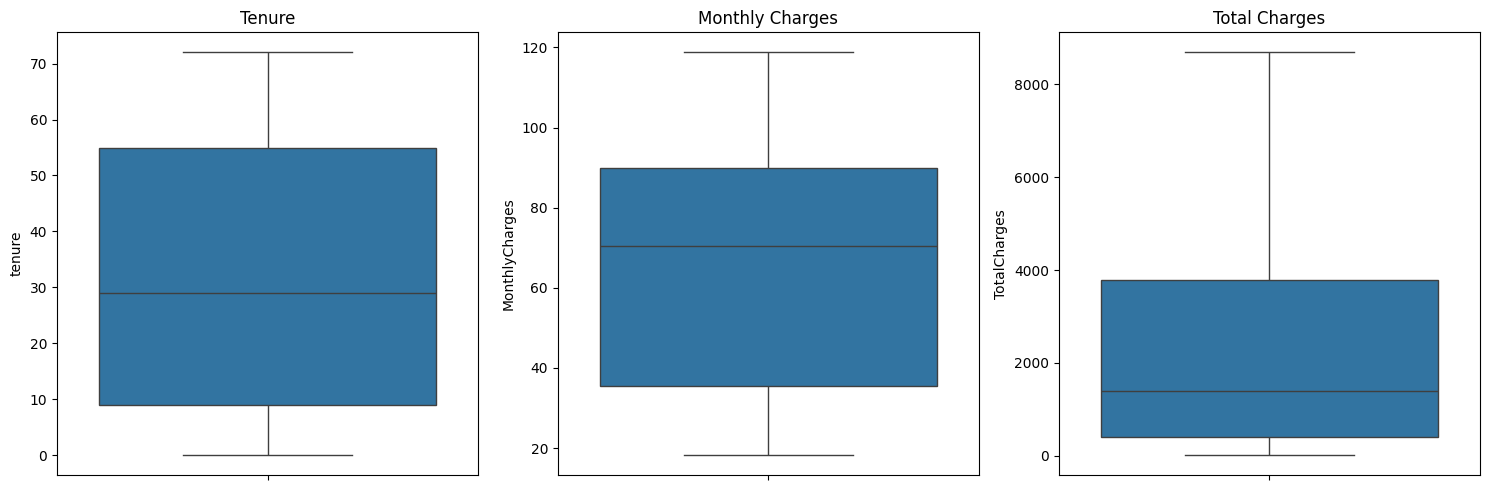

In [13]:
# Boxplots für die numerischen Variablen

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # Erstellung von Subplots

sns.boxplot(data=df, y='tenure', ax=axes[0])
axes[0].set_title('Tenure')

sns.boxplot(data=df, y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges')

sns.boxplot(data=df, y='TotalCharges', ax=axes[2])
axes[2].set_title('Total Charges')

plt.tight_layout()
plt.show() 

In [ ]:
df.describe()

In [14]:
df.groupby('Churn').agg({
    'tenure': ['median'],
    'MonthlyCharges': ['median'],
    'TotalCharges': ['median']
})

,tenure,MonthlyCharges,TotalCharges
,median,median,median
Churn,,,
No,38.0,64.425,1679.525
Yes,10.0,79.650,703.550


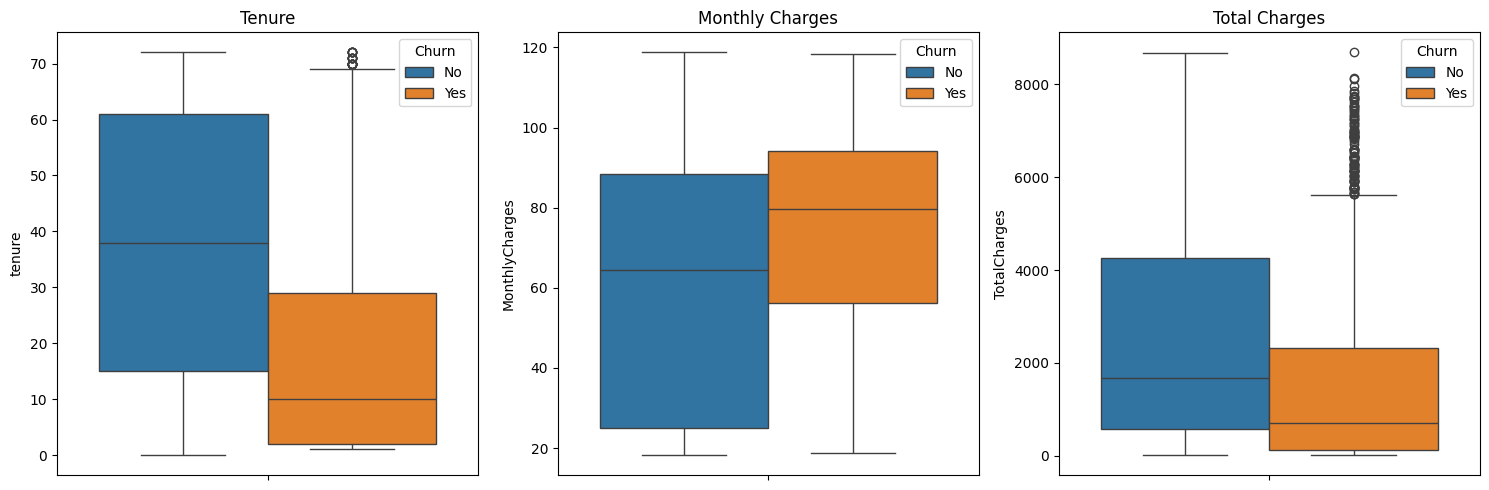

In [15]:
# Gleiche Plots in Abhängigkeit von Churn

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # Erstellung von Subplots

sns.boxplot(data=df, y='tenure', hue='Churn', ax=axes[0])
axes[0].set_title('Tenure')

sns.boxplot(data=df, y='MonthlyCharges', hue='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges')

sns.boxplot(data=df, y='TotalCharges', hue='Churn', ax=axes[2])
axes[2].set_title('Total Charges')

plt.tight_layout()
plt.show()

#https://stackoverflow.com/questions/17725927/boxplots-in-matplotlib-markers-and-outliers

<Axes: xlabel='Contract', ylabel='tenure'>

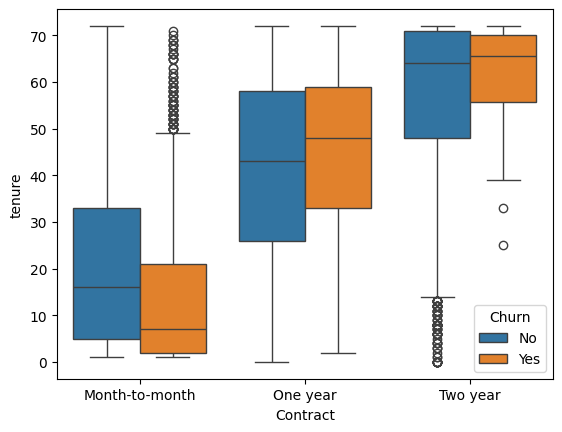

In [16]:
# Vertragslaufzeit abhängig von der Vertragsart nach Churn/Non-Churn

sns.boxplot(data=df, x='Contract', y='tenure', hue='Churn')

### Verteilungen numerische Variablen

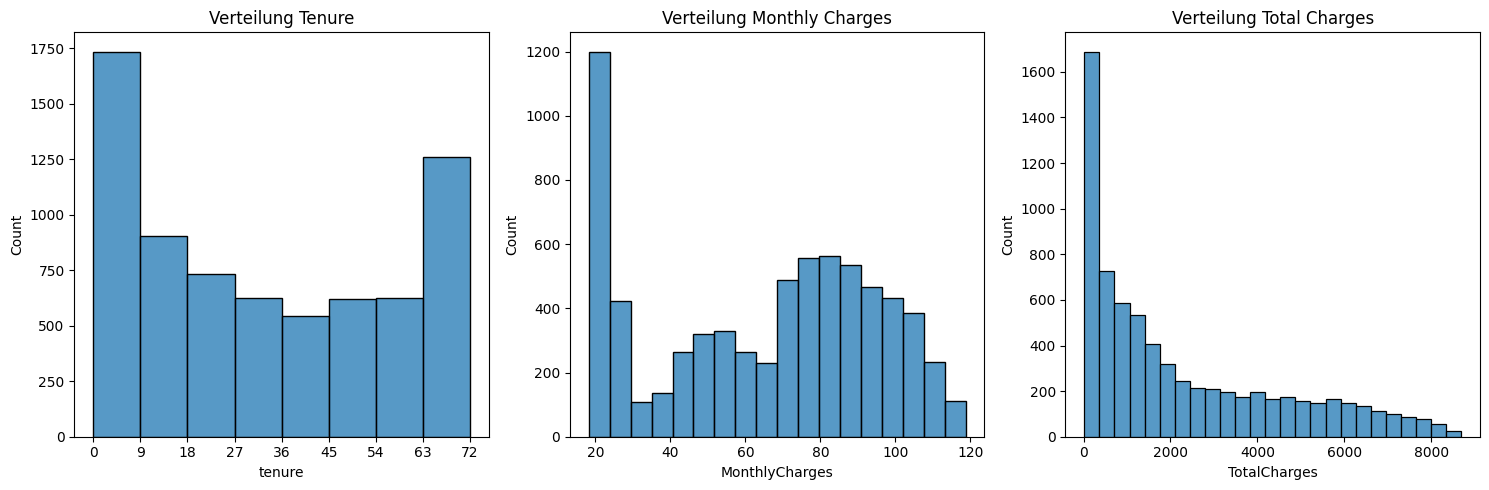

In [17]:
# Histogramme

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Option A
#sns.histplot(data=df, x='tenure', ax=axes[0])
#axes[0].set_title('Verteilung Tenure')

# Option B
#sns.histplot(data=df, x='tenure', bins=20, ax=axes[0])
#axes[0].set_title('Verteilung Tenure')

# Option C
tenure_bins = np.linspace(0, 72, 9)
sns.histplot(data=df, x='tenure', bins=tenure_bins, ax=axes[0])
axes[0].set_xticks(tenure_bins)
axes[0].set_title('Verteilung Tenure')
 
sns.histplot(data=df, x='MonthlyCharges', ax=axes[1])
axes[1].set_title('Verteilung Monthly Charges')

sns.histplot(data=df, x='TotalCharges', ax=axes[2])
axes[2].set_title('Verteilung Total Charges')

plt.tight_layout()
plt.show()

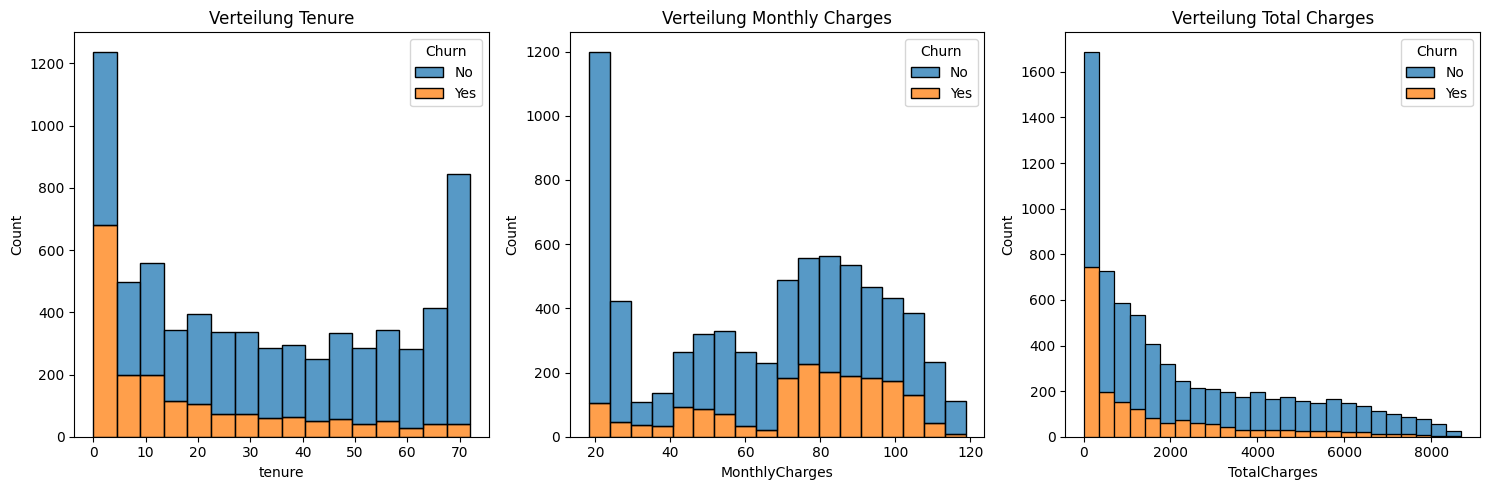

In [18]:
# In Abhängigkeit von Churn

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', ax=axes[0]) # ohne stack: Überlappen
axes[0].set_title('Verteilung Tenure')
 
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', ax=axes[1])
axes[1].set_title('Verteilung Monthly Charges')

sns.histplot(data=df, x='TotalCharges', hue='Churn', multiple='stack', ax=axes[2])
axes[2].set_title('Verteilung Total Charges')

plt.tight_layout()
plt.show()

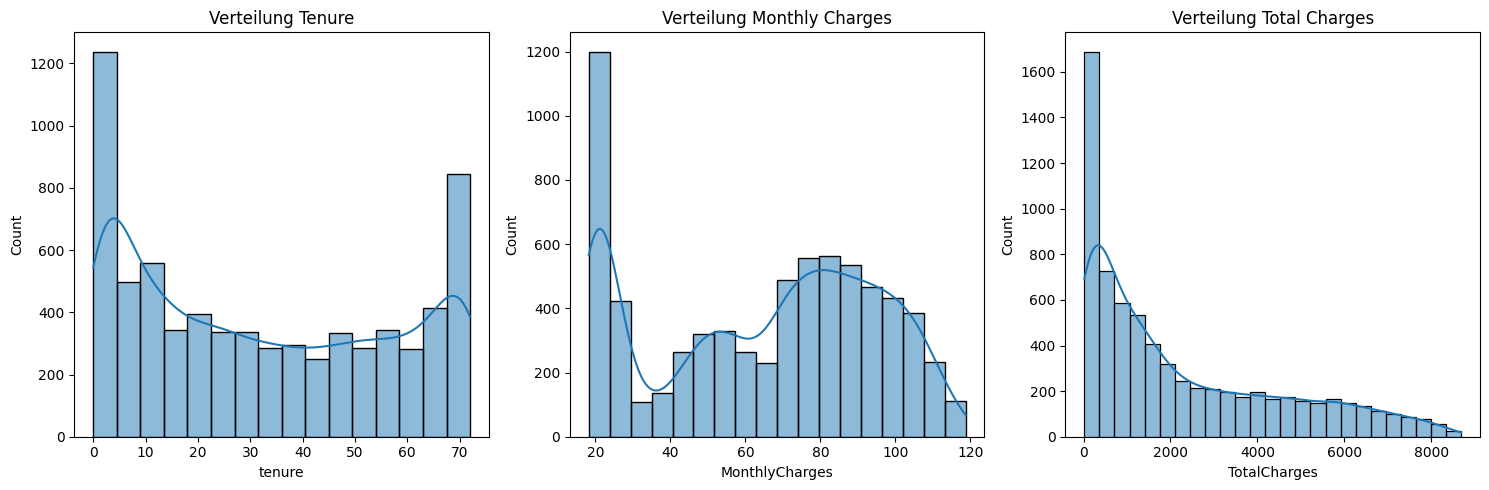

In [19]:
# Mit Kernel Density Estimation (https://seaborn.pydata.org/tutorial/distributions.html#tutorial-kde)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=df, x='tenure', kde=True, ax=axes[0])
axes[0].set_title('Verteilung Tenure')
 
sns.histplot(data=df, x='MonthlyCharges', kde=True, ax=axes[1])
axes[1].set_title('Verteilung Monthly Charges')

sns.histplot(data=df, x='TotalCharges', kde=True, ax=axes[2])
axes[2].set_title('Verteilung Total Charges')

plt.tight_layout()
plt.show()

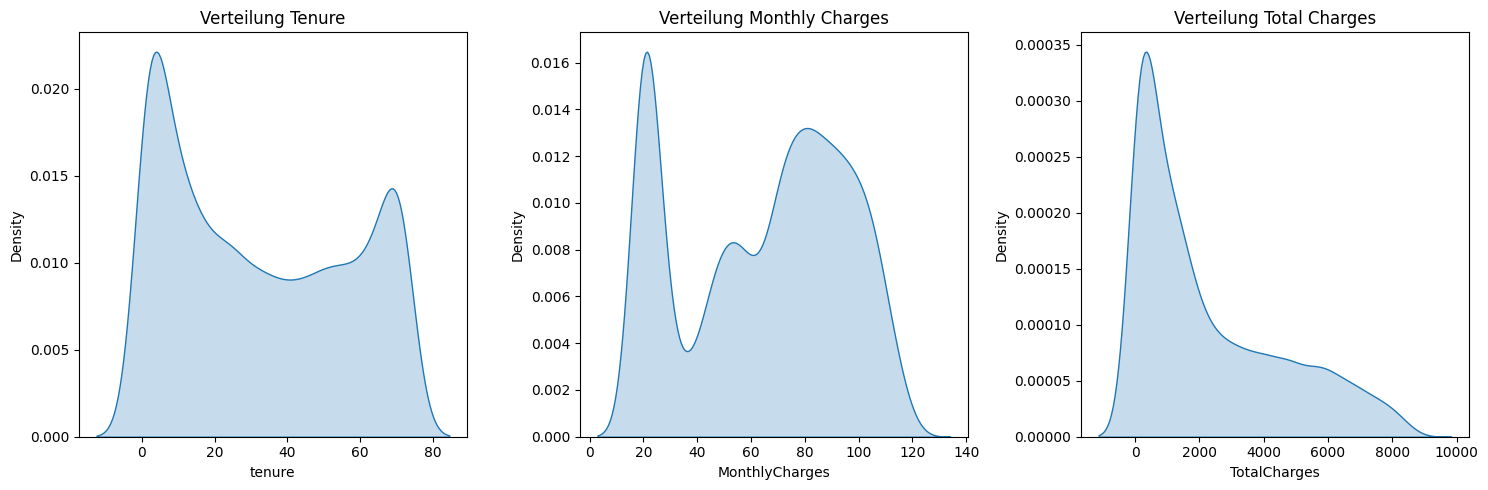

In [20]:
# KDE Plots Tenure, MonthlyCharges, TotalCharges

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=df, x='tenure', ax=axes[0], fill=True)
axes[0].set_title('Verteilung Tenure')

sns.kdeplot(data=df, x='MonthlyCharges', ax=axes[1], fill=True)
axes[1].set_title('Verteilung Monthly Charges')

sns.kdeplot(data=df, x='TotalCharges', ax=axes[2], fill=True)
axes[2].set_title('Verteilung Total Charges')

plt.tight_layout()
plt.show()

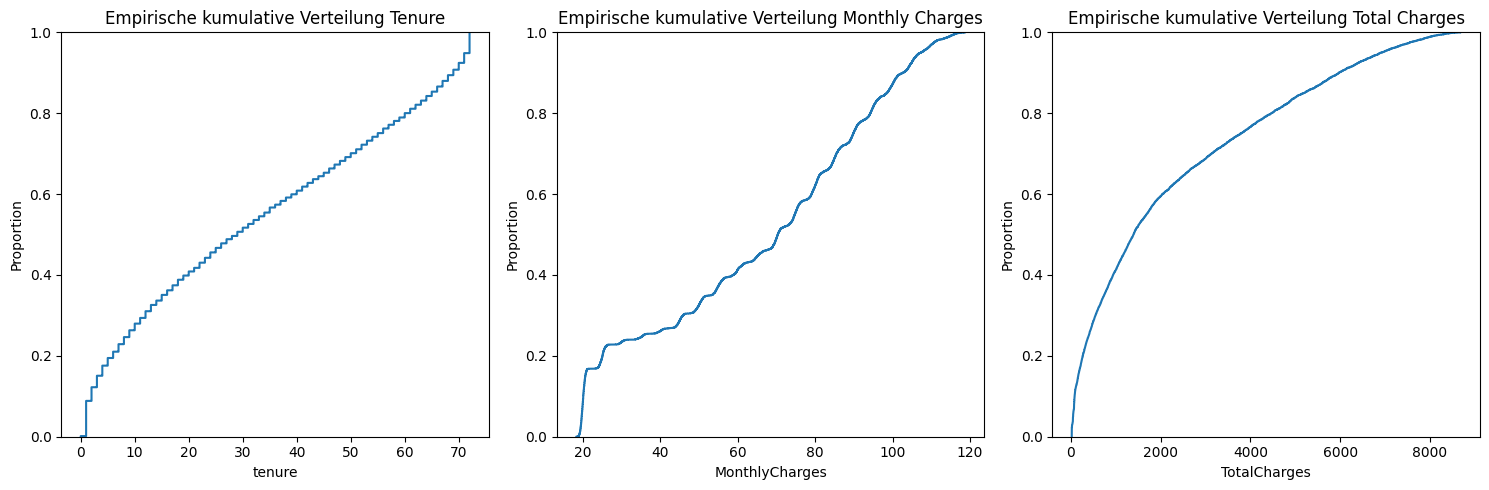

In [21]:
# Empirische kumulative Verteilungen

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.ecdfplot(data=df, x='tenure', ax=axes[0], stat="proportion")
axes[0].set_title('Empirische kumulative Verteilung Tenure')

sns.ecdfplot(data=df, x='MonthlyCharges', ax=axes[1], stat="proportion")
axes[1].set_title('Empirische kumulative Verteilung Monthly Charges')

sns.ecdfplot(data=df, x='TotalCharges', ax=axes[2], stat="proportion")
axes[2].set_title('Empirische kumulative Verteilung Total Charges')

plt.tight_layout()
plt.show()

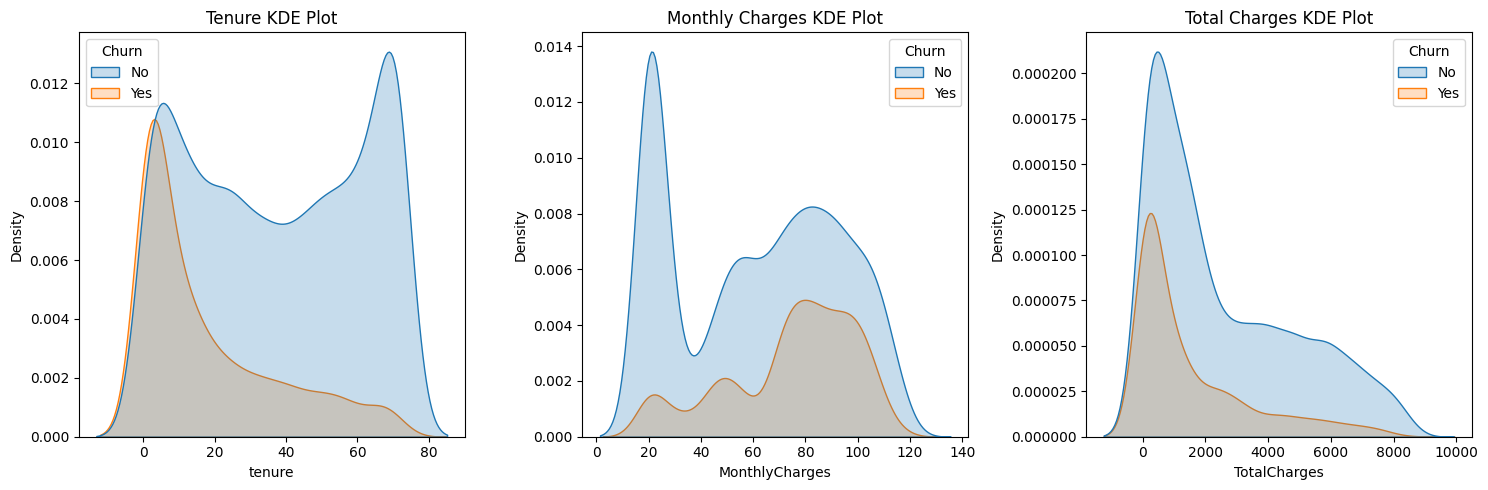

In [22]:
# KDE in Abhängigkeit von Churn

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=df, x='tenure', hue='Churn', ax=axes[0], fill=True)
axes[0].set_title('Tenure KDE Plot')

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[1], fill=True)
axes[1].set_title('Monthly Charges KDE Plot')

sns.kdeplot(data=df, x='TotalCharges', hue='Churn', ax=axes[2], fill=True)
axes[2].set_title('Total Charges KDE Plot')

plt.tight_layout()
plt.show()

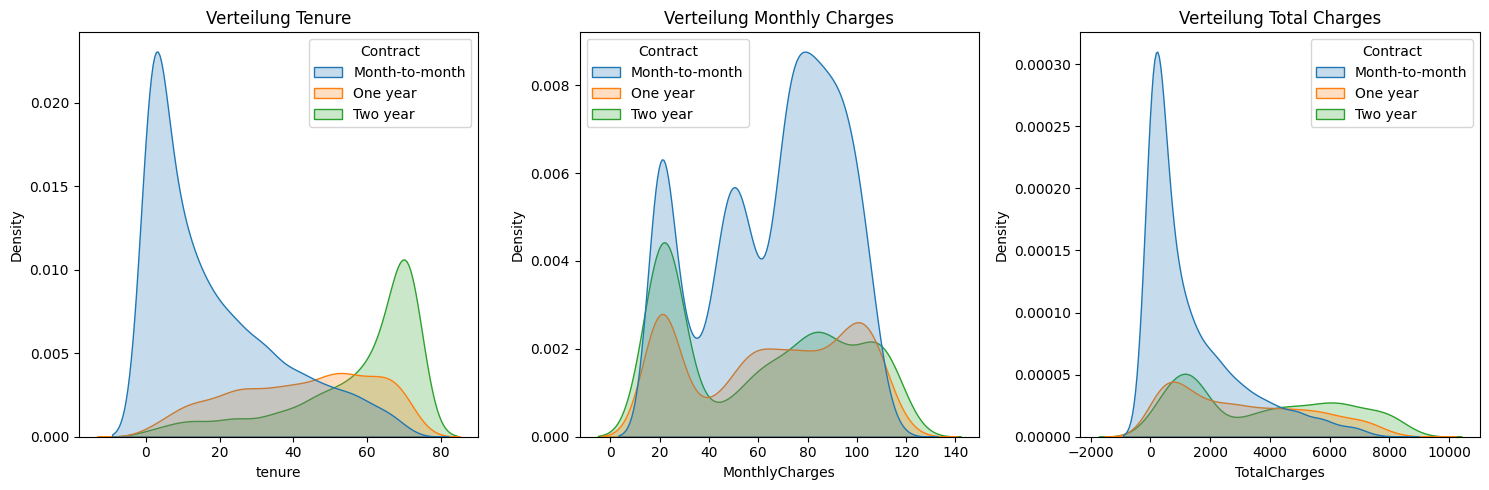

In [23]:
# In Abhängigkeit der Vertragsart

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=df, x='tenure', hue='Contract', ax=axes[0], fill=True)
axes[0].set_title('Verteilung Tenure')

sns.kdeplot(data=df, x='MonthlyCharges', hue='Contract', ax=axes[1], fill=True)
axes[1].set_title('Verteilung Monthly Charges')

sns.kdeplot(data=df, x='TotalCharges', hue='Contract', ax=axes[2], fill=True)
axes[2].set_title('Verteilung Total Charges')

plt.tight_layout()
plt.show()

### Korrelationen

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826164
MonthlyCharges  0.247900        1.000000      0.651182
TotalCharges    0.826164        0.651182      1.000000


<Axes: >

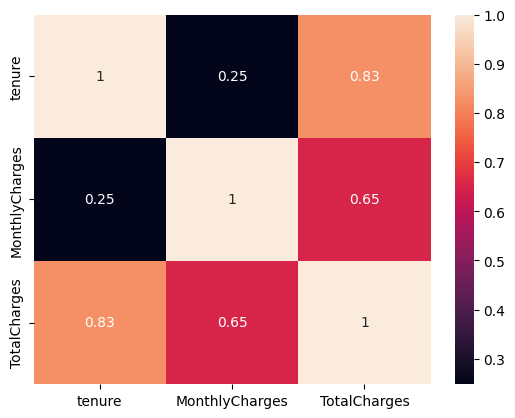

In [24]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr())
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True)

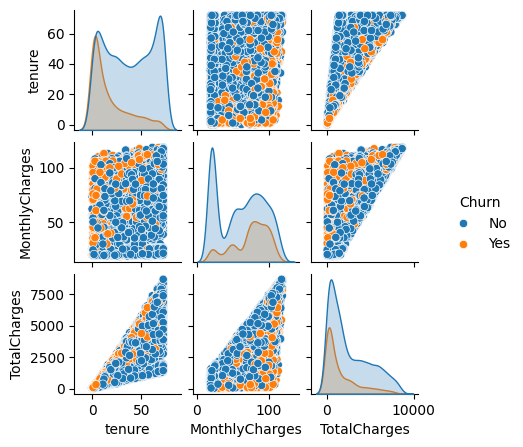

In [25]:
sns.pairplot(df,hue="Churn", height=1.5)